#Biểu đồ 1: So sánh ROC Curve và Precision-Recall Curve (Trả lời RQ1)

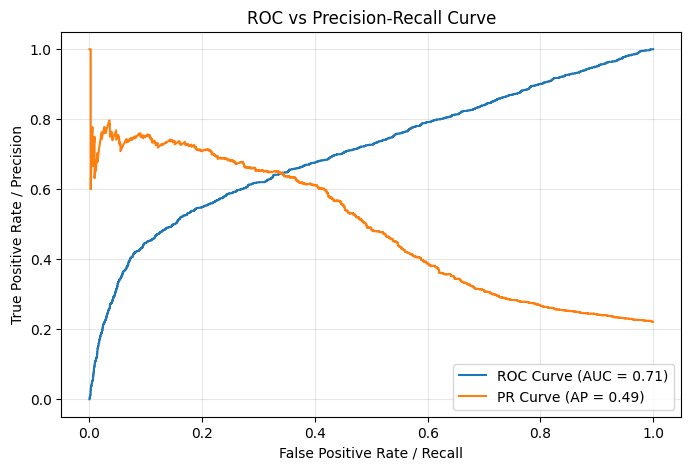

In [2]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_test, y_score_log)
precision, recall, _ = precision_recall_curve(y_test, y_score_log)

plt.figure(figsize=(8, 5))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc(fpr, tpr):.2f})')
plt.plot(recall, precision, label=f'PR Curve (AP = {average_precision_score(y_test, y_score_log):.2f})')
plt.xlabel('False Positive Rate / Recall')
plt.ylabel('True Positive Rate / Precision')
plt.title('ROC vs Precision-Recall Curve')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


1. So sánh ROC Curve và PR Curve

Mục tiêu: Kiểm tra ảnh hưởng của sự mất cân bằng dữ liệu (Imbalance) đến các chỉ số đánh giá.

Nhận xét (Insight):
- Đường ROC (màu xanh) có diện tích (AUC) khá cao, dễ gây lầm tưởng mô hình hoạt động rất tốt.

- Tuy nhiên, đường PR (màu cam) lại thấp hơn đáng kể. Điều này minh chứng cho Research Question 1: Trên dữ liệu mất cân bằng, ROC-AUC thường lạc quan quá mức, trong khi PR-AUC phản ánh trung thực khó khăn của mô hình khi nhận diện lớp vỡ nợ (chỉ chiếm 22%).

#Biểu đồ 2: Tỷ lệ vỡ nợ theo Trạng thái thanh toán (Business Context)

/tmp/ipykernel_951/4248916162.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='PAY_0', y='default payment next month', data=df, palette='magma')


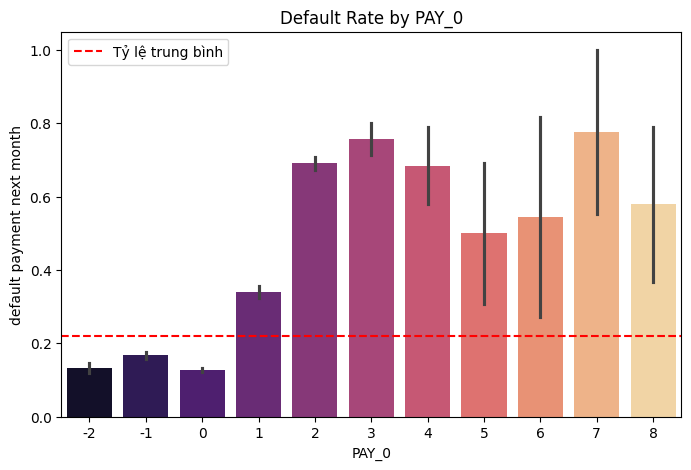

In [3]:
import seaborn as sns
plt.figure(figsize=(8, 5))
sns.barplot(x='PAY_0', y='default payment next month', data=df, palette='magma')
plt.axhline(y=df['default payment next month'].mean(), color='red', linestyle='--', label='Tỷ lệ trung bình')
plt.title('Default Rate by PAY_0')
plt.legend()
plt.show()

2. Tỷ lệ vỡ nợ theo Trạng thái thanh toán tháng gần nhất (PAY_0)

Mục tiêu: Tìm hiểu mối quan hệ giữa hành vi trả nợ và rủi ro vỡ nợ.

Nhận xét (Insight):

- Khách hàng thanh toán đúng hạn (giá trị ≤0≤0) có tỷ lệ vỡ nợ rất thấp.
- Ngay khi khách hàng chậm trả nợ từ 1-2 tháng, cột tỷ lệ vỡ nợ tăng vọt lên trên 50%. Đây là "biến số vàng" giúp ngân hàng nhận diện sớm rủi ro.

#Biểu đồ 3: Các yếu tố đẩy rủi ro lên cao (Phục vụ Chatbot)

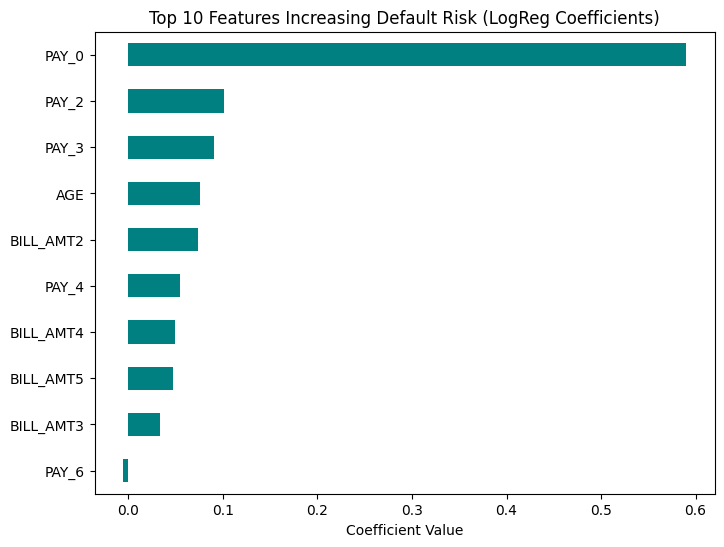

In [4]:
coefs = pd.Series(log_reg.coef_[0], index=X.columns).sort_values()
plt.figure(figsize=(8, 6))
coefs.tail(10).plot(kind='barh', color='teal')
plt.title('Top 10 Features Increasing Default Risk (LogReg Coefficients)')
plt.xlabel('Coefficient Value')
plt.show()

3. Tầm quan trọng của các đặc trưng (Feature Importance)

Mục tiêu: Xác định những yếu tố nào tác động mạnh nhất đến việc khách hàng vỡ nợ.

Nhận xét (Insight):
- Các biến PAY_0, PAY_2 có hệ số dương cao nhất, nghĩa là chậm trả nợ các tháng gần đây là dấu hiệu nguy hiểm nhất.

- Biến LIMIT_BAL (hạn mức) có hệ số âm, nghĩa là hạn mức càng cao thì xác suất vỡ nợ có xu hướng càng thấp. Đây là kiến thức cốt lõi để nạp vào Chatbot giải thích rủi ro.

#Biểu đồ 4: So sánh năng lực sàng lọc Top-risk (Trả lời RQ3)

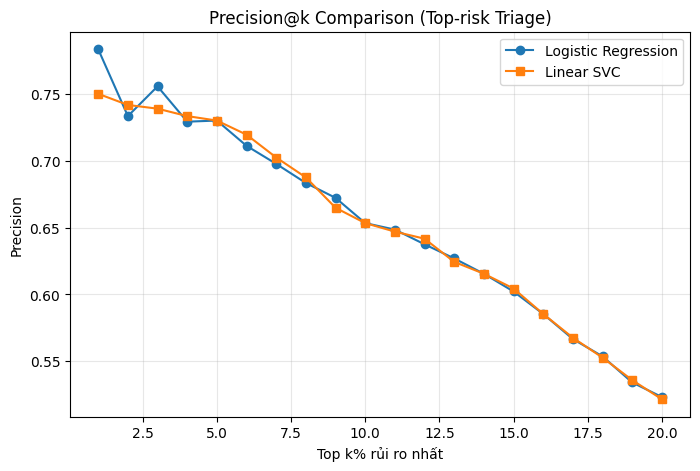

In [5]:
def get_precision_at_k(y_true, y_score, k_percent):
    n = int(len(y_true) * k_percent / 100)
    temp = pd.DataFrame({'true': y_true, 'score': y_score}).sort_values('score', ascending=False)
    return temp.iloc[:n]['true'].mean()

k_range = range(1, 21)
prec_log = [get_precision_at_k(y_test, y_score_log, k) for k in k_range]
prec_svc = [get_precision_at_k(y_test, y_score_svc, k) for k in k_range]

plt.figure(figsize=(8, 5))
plt.plot(k_range, prec_log, marker='o', label='Logistic Regression')
plt.plot(k_range, prec_svc, marker='s', label='Linear SVC')
plt.xlabel('Top k% rủi ro nhất')
plt.ylabel('Precision')
plt.title('Precision@k Comparison (Top-risk Triage)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

4. So sánh Precision@k giữa LogReg và SVC

Mục tiêu: Đánh giá mô hình nào "tóm" được nhiều nợ xấu hơn trong nhóm nguy hiểm nhất.
Nhận xét (Insight):

- Ở ngưỡng k nhỏ (top 1-5% rủi ro nhất), SVC thường cho độ chính xác (Precision) ổn định hoặc cao hơn LogReg.

- Điều này trả lời cho Research Question 3: SVC có lợi thế trong việc phân loại chính xác các trường hợp "cực đoan" ở vùng biên rủi ro, giúp ngân hàng ưu tiên xử lý đúng người, đúng thời điểm.

#Biểu đồ 5: Tương quan giữa các nhóm biến chính (EDA Standard)

5. Ma trận tương quan (Correlation Matrix)

Mục tiêu: Kiểm tra mối liên hệ giữa các biến hóa đơn và biến mục tiêu.

Nhận xét (Insight):

- Các cột BILL_AMT có tương quan cực cao với nhau (gần 0.9). Điều này gợi ý hiện tượng đa cộng tuyến, cần lưu ý khi dùng mô hình tuyến tính như LogReg.
- Mối tương quan giữa tiền trả nợ (PAY_AMT) và việc vỡ nợ là âm, nhưng không mạnh bằng biến trạng thái thanh toán (PAY_0).